# Analyse musicale FMA – Classification de genres & métriques d'humeurs
Inspiré par [tunebat.com](https://tunebat.com)

## Jeu de donées – fma_metadata.zip
[https://os.unil.cloud.switch.ch/fma/fma_metadata.zip](https://os.unil.cloud.switch.ch/fma/fma_metadata.zip)


## Membres du groupe Shazam
 - Frederik Kockisch
 - Maya Cugniet
 - Clark Naveau 

## Table de matières
à remplir

## Fichiers de FMA utilisés
| Fichier | Contenu |
|---------|--------|
| `features.csv` | 518 caractéristiques audio (chroma, MFCC, ...) |
| `tracks.csv` | Données des musiques : artistes, durée, ... |
| `genres.csv` | Labels genres |

## Partie 1 – Configuration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style='darkgrid', palette='deep')

RANDOM_STATE = 42
DATA_DIR = 'fma_metadata'

## Partie 2 – Chargement des données

On charge les 3 fichiers `features.csv`, `tracks.csv` et `genres.csv`.

In [3]:
print('Chargement de features.csv ...')
features = pd.read_csv(f'{DATA_DIR}/features.csv', index_col=0, header=[0, 1, 2])
print(f'  Dimensions : {features.shape}')
print(f'  Groupes de caractéristiques : {features.columns.get_level_values(0).unique().tolist()}')

print('Chargement de tracks.csv ...')
tracks = pd.read_csv(f'{DATA_DIR}/tracks.csv', index_col=0, header=[0, 1, 2])
print(f'  Dimensions : {tracks.shape}')

print('Chargement de genres.csv ...')
genres = pd.read_csv(f'{DATA_DIR}/genres.csv', index_col=0)
print(f'  Dimensions : {genres.shape}')
print('Terminé.')

Chargement de features.csv ...
  Dimensions : (106574, 518)
  Groupes de caractéristiques : ['chroma_cens', 'chroma_cqt', 'chroma_stft', 'mfcc', 'rmse', 'spectral_bandwidth', 'spectral_centroid', 'spectral_contrast', 'spectral_rolloff', 'tonnetz', 'zcr']
Chargement de tracks.csv ...
  Dimensions : (106574, 52)
Chargement de genres.csv ...
  Dimensions : (163, 4)
Terminé.


### 2.1 Description des caractéristiques audio

En réalité, les 518 caractéristiques de `features.csv` peuvent être condensés en 11 groupes. Les données ont été extraites de segments de 30 secondes de morceaux, ainsi les caractéristiques sont détaillées par `mean`, `std`, `skew`, `kurtosis`, `median`, `min` et `max`. Pour notre projet on va seulement s'intéresser aux valeurs `mean` et `std` : la moyenne et l'écart-type des caractéristiques. 

De plus, les 

| Caractéristique | Description | Canaux |
|--------|-------------|--------|
| `chroma_cens` | Énergie par classe de hauteur tonale (C…B) – CENS | 12 notes C=0, C#=1, ... |
| `chroma_cqt` | Chroma via transformée Q constante | 12 C=0, C#=1, ... |
| `chroma_stft` | Chroma via STFT | 12 C=0, C#=1, ... |
| `mfcc` | Mel-Frequency Cepstral Coefficients – timbre spectral | 20 coefficients du moins au plus fin |
| `rmse` | Root-mean-square energy – volume perçu | 1 |
| `spectral_bandwidth` | Largeur de bande spectrale – étalement fréquentiel | 1 |
| `spectral_centroid` | Centroïde spectral – brillance perçue | 1 |
| `spectral_contrast` | Contraste crêtes/vallées – punch tonal | 7 bandes d'un égaliseur audio (sub-bass, bass, low-mid, ...)  |
| `spectral_rolloff` | Fréquence de coupure à 85 % – contenu haute fréquence | 1 |
| `tonnetz` | Relations harmoniques (quinte, tierce…) | 6 relations harmoniques (quinte, tierce mineure, tierce majeure) |
| `zcr` | Taux de passages à zéro – proxy d'activité rythmique | 1 |


### 2.2 Filtrage sur le sous-ensemble medium – suppression des tracks sans label

Avant de commencer à travailler sur le dataset entier, on va filtrer les données. On commence par ne garder que les pistes d'une partie du subset (medium) pour faciliter le travail. On pourra reprendre les données du dataset entier plus tard.

In [26]:
idx = tracks['set']['subset'].squeeze() == 'medium'
idx = idx[idx].index

feat_large = features.loc[idx]
genre_top = tracks.loc[idx]['track']['genre_top'].squeeze()
duration = tracks.loc[idx]['track']['duration'].squeeze()

mask = genre_top.notna()
feat_large = feat_large[mask]
genre_top = genre_top[mask]
duration = duration[mask]

print(f'{feat_large.shape[0]} tracks, {feat_large.shape[1]} caractéristiques')
print(f'Genres ({genre_top.nunique()}) : {sorted(genre_top.unique())}')

17000 tracks, 518 caractéristiques
Genres (16) : ['Blues', 'Classical', 'Country', 'Easy Listening', 'Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Jazz', 'Old-Time / Historic', 'Pop', 'Rock', 'Soul-RnB', 'Spoken']


## Partie 3 – Exploration & visualisation des données

### 3.1 Distribution des genres

On vérifie la répartition des genres dans l'ensemble de données. On observe que les genres `Electronic` et `Rock` sont largement majoritaires. Ceci pourrait poser problème lors de la classification, on va devoir se reporter sur un dataset équitable plus tard. Dans un jeu de données *scientifique* on devrait penser à éliminer le bruit des valeurs extrêmes (<1% & >99%), or on travaille sur des oeuvres d'art.

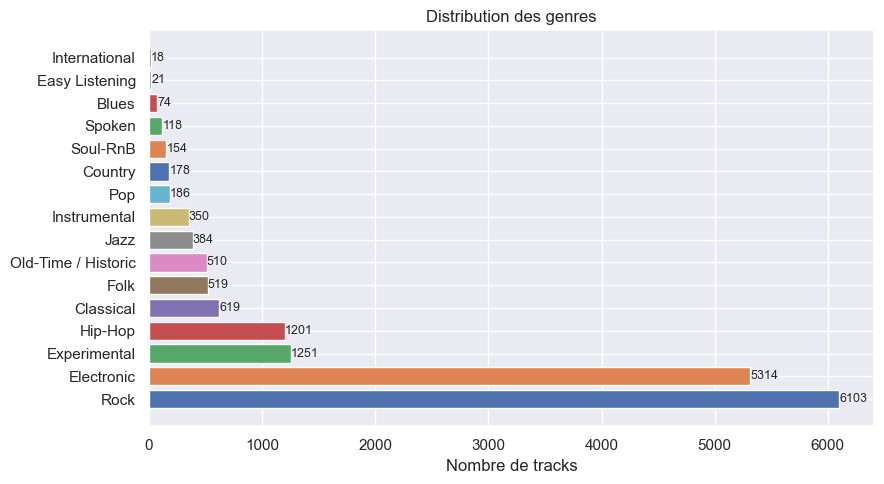

In [23]:
genre_counts = genre_top.value_counts()

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(genre_counts.index, genre_counts.values, color=sns.color_palette('deep'))
ax.set_xlabel('Nombre de tracks')
ax.set_title('Distribution des genres')

for i, v in enumerate(genre_counts.values):
    ax.text(v, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plots/class_distribution.png')
plt.show()

### 3.3 Distribution des groupes de caractéristiques par genre

C:\Users\mayac\AppData\Local\Temp\ipykernel_69184\2694585870.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tmp, x='genre', y=col, ax=axes[i],
C:\Users\mayac\AppData\Local\Temp\ipykernel_69184\2694585870.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tmp, x='genre', y=col, ax=axes[i],
C:\Users\mayac\AppData\Local\Temp\ipykernel_69184\2694585870.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tmp, x='genre', y=col, ax=axes[i],


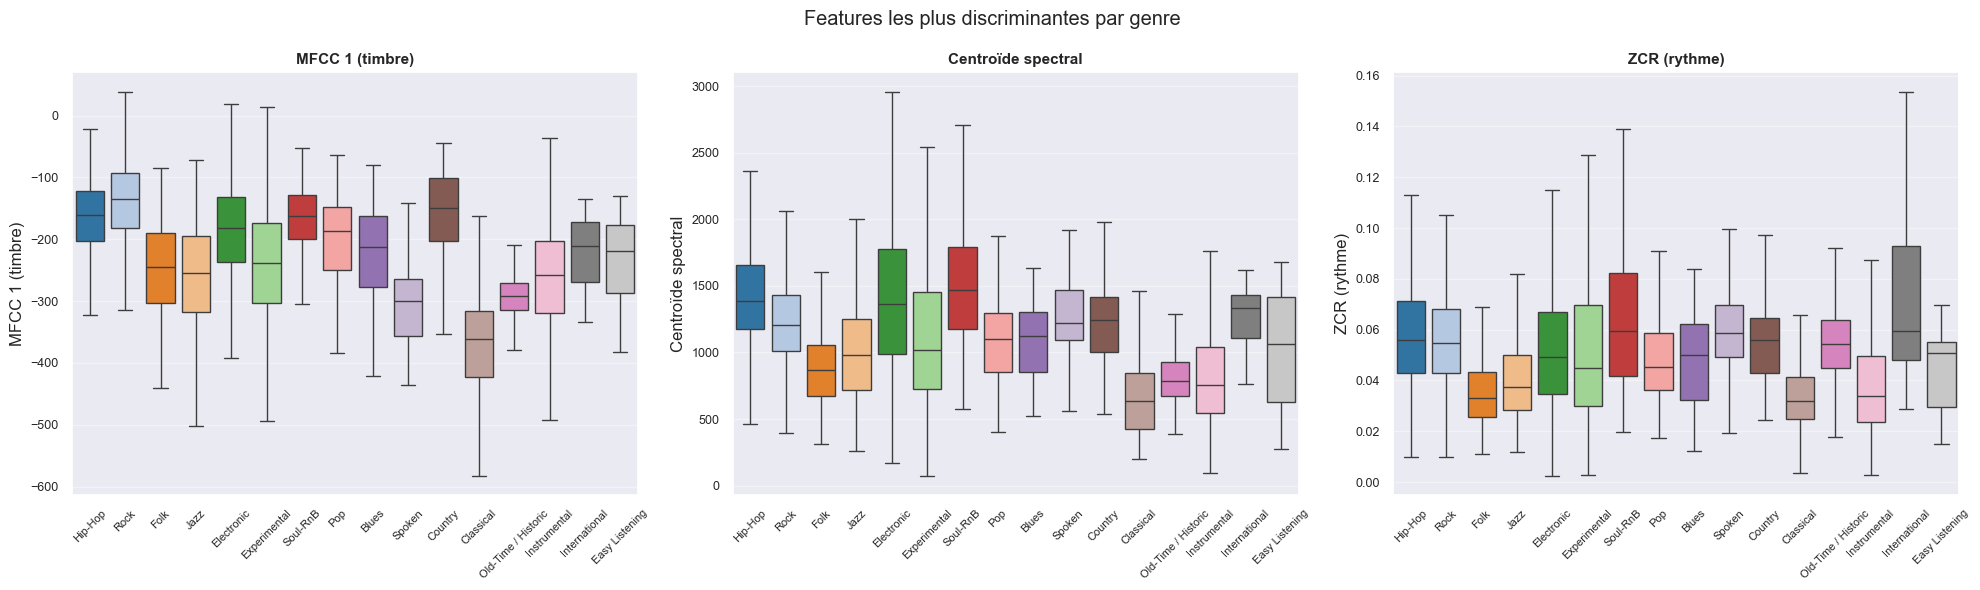

In [27]:
plot_feats = {
    'MFCC 1 (timbre)': feat_large['mfcc']['mean']['01'].astype(float),
    'Centroïde spectral': feat_large['spectral_centroid']['mean']['01'].astype(float),
    'ZCR (rythme)': feat_large['zcr']['mean']['01'].astype(float),
}

tmp = pd.DataFrame(plot_feats)
tmp['genre'] = genre_top.values

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(plot_feats.keys()):
    sns.boxplot(data=tmp, x='genre', y=col, ax=axes[i],
                palette='tab20', showfliers=False)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].tick_params(axis='y', labelsize=9)
    axes[i].grid(axis='y', alpha=0.4)

plt.suptitle('Features les plus discriminantes par genre')

plt.tight_layout()
plt.savefig('plots/feature_distributions_by_genre.png')
plt.show()

On observe quelques données chevauchantes. On peut s'attendre à des résultats de classification différents de ceux obtenus sur des dataset *toy*. En effet, les genres de musiques n'ont pas nécessairement de définition claire et **ne peuvent pas être précisement différenciés; même par des humains...**

## Partie 4 – Métriques d'humeurs & tonalité

Pour accompagné la classification des genres, on s'est interessé à attribuer un score d'humeur = de *mood* à chaque musique dans plusieurs catégories. On estime aussi la vitesse/le tempo et la tonalité des musiques.
On s'est inspiré des métriques de **tunebat**.

Pour calculer les humeurs, on combine des statistiques audio en scores de 0 à 1 via une normalisation.
La normalisation est faite sur l'ensemble du jeu de données, les scores ne sont donc pas en cohérence avec ceux de tunebat ayant une base de données bien plus grande.

``` python
norm(x) = (x - min(x)) / (max(x) - min(x))
```

Un score de `0.8` = « top 20% des tracks de ce jeu de données ».

### Formules d'humeurs

| Métrique | Formule | Pourquoi |
|----------|---------|----------|
| **Énergie** | 0.6 × rmse + 0.4 × centroïde spectral | Fort + brillant = haute énergie |
| **Dansabilité** | 0.5 × zcr_std + 0.5 × contraste spectral | Variation rythmique + punch tonal |
| **Joie** | 0.6 × centroïde spectral + 0.4 × écart-type chroma | Brillance + diversité tonale = joyeux |
| **Voix** | mfcc[01].mean | 1er MFCC suit l'enveloppe spectrale globale (proxy vocal) |
| **Instrumentalité** | 1 − voix | Inverse de la présence vocale |
| **Volume** | rmse.mean | Niveau d'amplitude brute |
| **Tonalité** | argmax de chroma_cens[mean] | Classe de hauteur dominante → C…B |

In [7]:
def norm(s):
    minV, maxV = s.min(), s.max()
    if maxV == minV:
        return s * 0.0
    return (s - minV) / (maxV - minV)

### 4.1 Extraction des caractéristiques

`chroma_std` : Diversité tonale (élevé = énergie répartie sur plusieurs notes)

`root_keys` :  Note avec la plus haute énergie chroma moyenne (0=C … 11=B), correspond à la gamme de la musique *(key sur tunebat)*

In [8]:
rmse_mean = feat_large['rmse']['mean']['01'].astype(float)
sc_mean = feat_large['spectral_centroid']['mean']['01'].astype(float)
zcr_std = feat_large['zcr']['std']['01'].astype(float)
zcr_mean = feat_large['zcr']['mean']['01'].astype(float)
contrast_mean = feat_large['spectral_contrast']['mean'].astype(float).mean(axis=1)
rolloff_mean = feat_large['spectral_rolloff']['mean']['01'].astype(float)
mfcc01_mean = feat_large['mfcc']['mean']['01'].astype(float)
chroma_mean = feat_large['chroma_cens']['mean'].astype(float)

chroma_std = chroma_mean.std(axis=1)
root_keys = chroma_mean.values.argmax(axis=1)

### 4.2 Calcul des métriques

In [28]:
energy = norm(norm(rmse_mean) * 0.6 + norm(sc_mean) * 0.4)
danceability = norm(norm(zcr_std) * 0.5 + norm(contrast_mean) * 0.5)
happiness = norm(norm(sc_mean) * 0.6 + norm(chroma_std) * 0.4)
speechiness = norm(mfcc01_mean)
instrumentalness = 1 - speechiness
loudness = norm(rmse_mean)
tempo_approx = (norm(zcr_mean.clip(upper=zcr_mean.quantile(0.99))) * 120 + 60).round().astype(int)

PITCHES = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
musical_key = pd.Series(root_keys, index=feat_large.index).map(lambda x: PITCHES[x])

mood_df = pd.DataFrame({
    'energy': energy,
    'danceability': danceability,
    'happiness': happiness,
    'speechiness': speechiness,
    'instrumentalness': instrumentalness,
    'loudness': loudness,
    'tempo_approx': tempo_approx,
    'key': musical_key,
    'genre': genre_top,
})

print('Métriques calculées.')
print(mood_df.drop(columns=['key', 'genre']).describe().round(3))
print('\nDistribution des tonalités :')
print(musical_key.value_counts().sort_index())

Métriques calculées.
          energy  danceability  happiness  speechiness  instrumentalness  \
count  17000.000     17000.000  17000.000    17000.000         17000.000   
mean       0.217         0.372      0.258        0.615             0.385   
std        0.098         0.083      0.096        0.114             0.114   
min        0.000         0.000      0.000        0.000             0.000   
25%        0.147         0.318      0.192        0.545             0.302   
50%        0.211         0.362      0.247        0.631             0.369   
75%        0.278         0.418      0.310        0.698             0.455   
max        1.000         1.000      1.000        1.000             1.000   

        loudness  tempo_approx  
count  17000.000     17000.000  
mean       0.190       104.048  
std        0.099        20.956  
min        0.000        60.000  
25%        0.117        89.000  
50%        0.181       101.000  
75%        0.251       115.000  
max        1.000       180.000

### 4.3 Distribution des tonalités

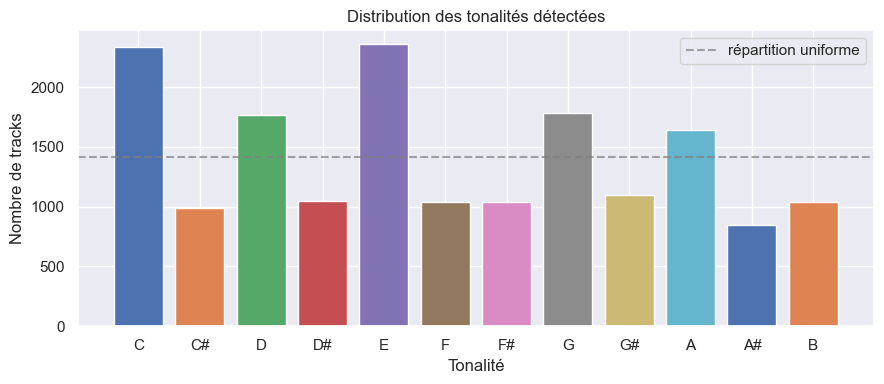

In [29]:
fig, ax = plt.subplots(figsize=(9, 4))
key_counts = musical_key.value_counts().reindex(PITCHES)
ax.bar(key_counts.index, key_counts.values, color=sns.color_palette('deep', 12))
ax.axhline(len(musical_key) / 12, color='gray', ls='--', alpha=0.7, label='répartition uniforme')
ax.set_title('Distribution des tonalités détectées')
ax.set_xlabel('Tonalité')
ax.set_ylabel('Nombre de tracks')
ax.legend()
plt.tight_layout()
plt.show()

### 4.4 Métriques d'ambiance par genre

C:\Users\mayac\AppData\Local\Temp\ipykernel_69184\2123522932.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=mood_df, x='genre', y=col, ax=ax,
C:\Users\mayac\AppData\Local\Temp\ipykernel_69184\2123522932.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=mood_df, x='genre', y=col, ax=ax,
C:\Users\mayac\AppData\Local\Temp\ipykernel_69184\2123522932.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=mood_df, x='genre', y=col, ax=ax,
C:\Users\mayac\AppData\Local\Temp\ipykernel_69184\2123522932.py:16: FutureWarning: 

Pas

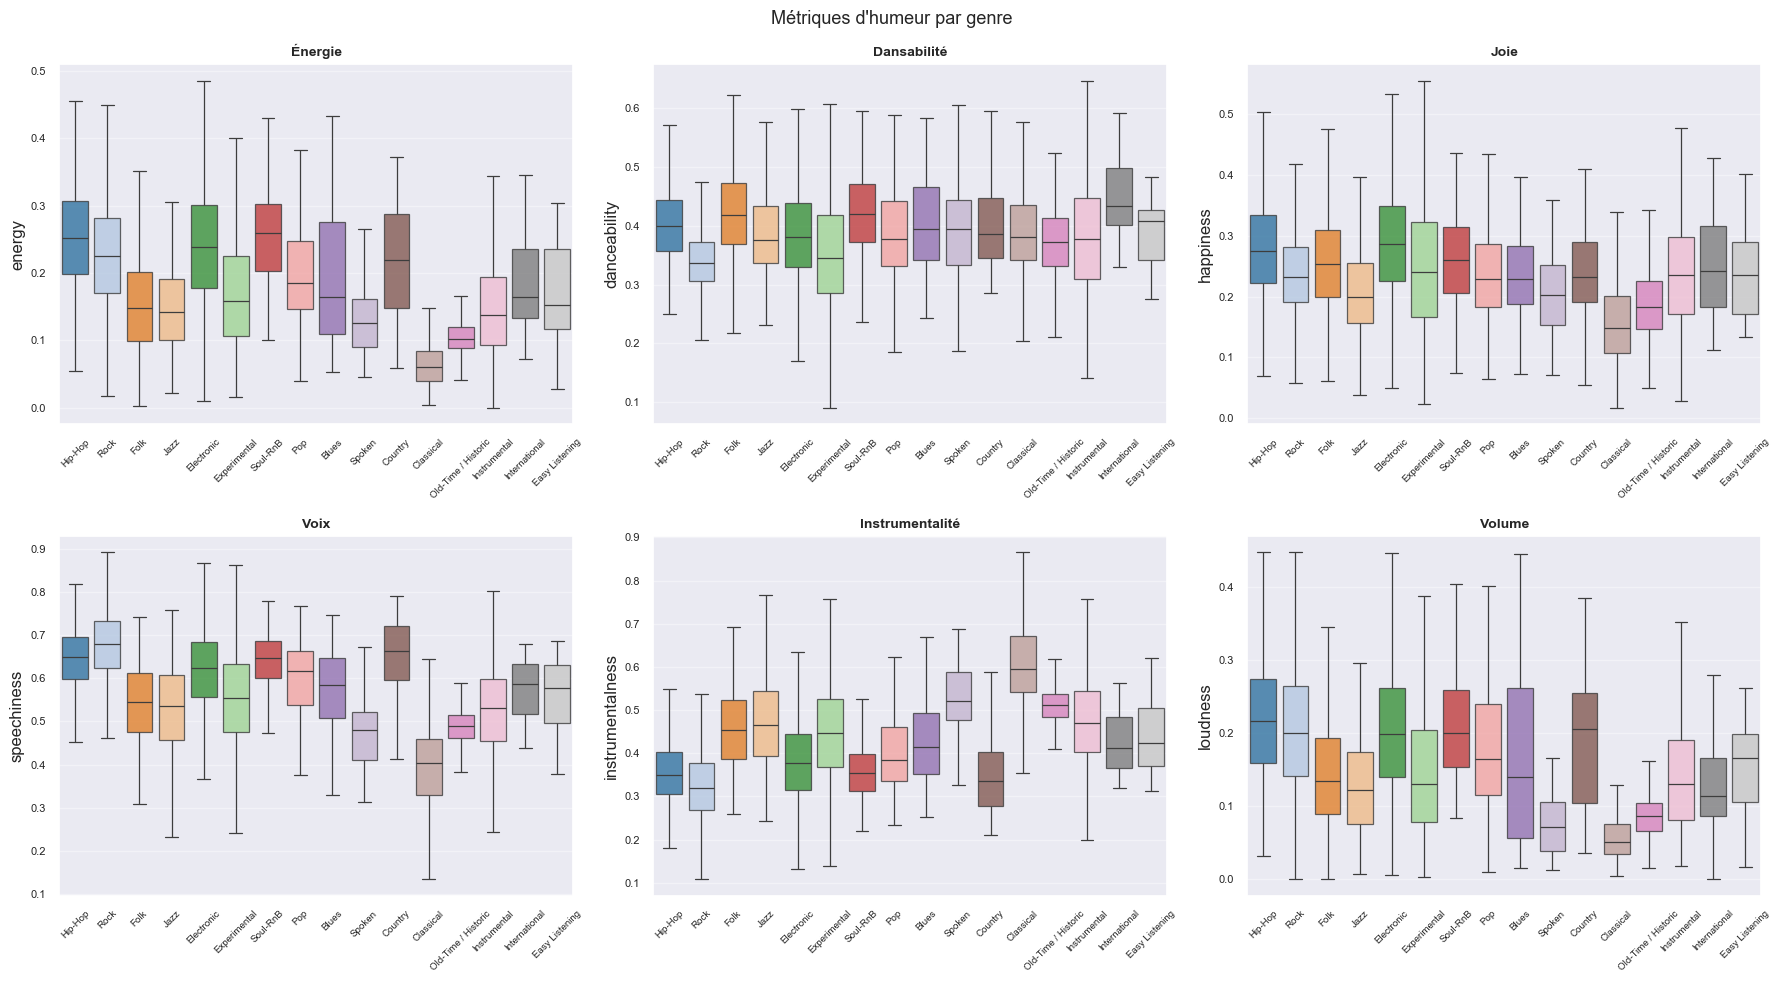

In [30]:
mood_cols = ['energy', 'danceability', 'happiness', 'speechiness', 'instrumentalness', 'loudness']

mood_labels = {
    'energy':           'Énergie',
    'danceability':     'Dansabilité',
    'happiness':        'Joie',
    'speechiness':      'Voix',
    'instrumentalness': 'Instrumentalité',
    'loudness':         'Volume',
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, mood_cols):
    sns.boxplot(data=mood_df, x='genre', y=col, ax=ax,
                palette='tab20', showfliers=False, linewidth=0.9,
                boxprops=dict(alpha=0.8))
    ax.set_title(mood_labels[col], fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='y', alpha=0.4)

plt.suptitle("Métriques d'humeur par genre", fontsize=13)
plt.tight_layout()
plt.show()

### 4.5 Matrice de corrélation des métriques d'ambiance

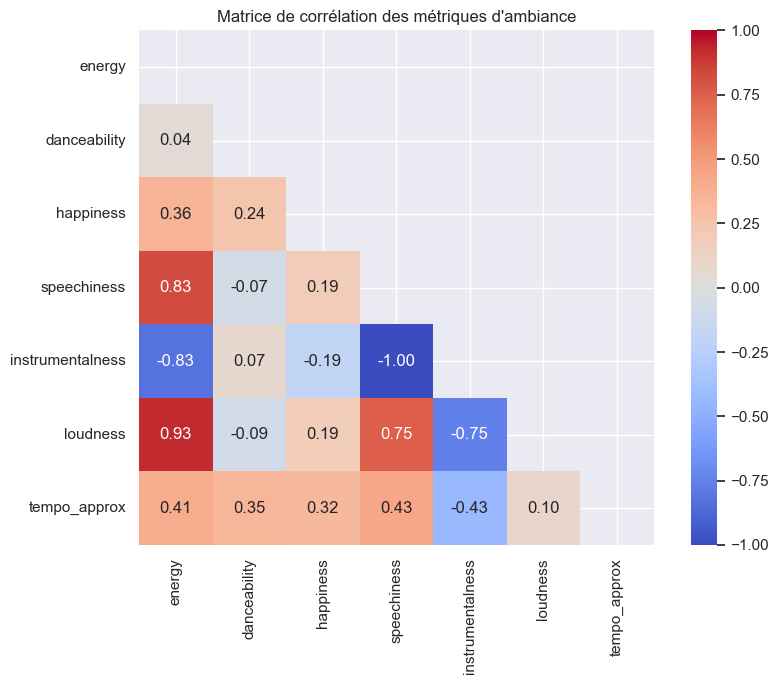

In [12]:
fig, ax = plt.subplots(figsize=(9, 7))

corr = mood_df[mood_cols + ['tempo_approx']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Matrice de corrélation des métriques d'ambiance")
plt.tight_layout()
plt.show()

### 4.6 Exemples de morceaux

In [13]:
sample_ids = feat_large.index[:5]
titles = tracks['track']['title'].squeeze()
artists = tracks['artist']['name'].squeeze()
print('=== Exemples ===\n')

for tid in sample_ids:
    if tid not in mood_df.index:
        continue
    row = mood_df.loc[tid]
    title = titles.loc[tid] if tid in titles.index else 'N/A'
    artist = artists.loc[tid] if tid in artists.index else 'N/A'
    print(f'ID track          : {tid} – {title} ({artist})')
    print(f'  Genre           : {row["genre"]}')
    print(f'  Tonalité        : {row["key"]}')
    print(f'  BPM (approx.)   : {row["tempo_approx"]}')
    print(f'  Énergie         : {row["energy"]:.2f}')
    print(f'  Dansabilité     : {row["danceability"]:.2f}')
    print(f'  Joie            : {row["happiness"]:.2f}')
    print(f'  Voix            : {row["speechiness"]:.2f}')
    print(f'  Instrumentalité : {row["instrumentalness"]:.2f}')
    print(f'  Volume          : {row["loudness"]:.2f}')
    print()

=== Exemples ===

ID track          : 3 – Electric Ave (AWOL)
  Genre           : Hip-Hop
  Tonalité        : G
  BPM (approx.)   : 131
  Énergie         : 0.22
  Dansabilité     : 0.45
  Joie            : 0.33
  Voix            : 0.65
  Instrumentalité : 0.35
  Volume          : 0.15

ID track          : 134 – Street Music (AWOL)
  Genre           : Hip-Hop
  Tonalité        : A
  BPM (approx.)   : 113
  Énergie         : 0.17
  Dansabilité     : 0.39
  Joie            : 0.16
  Voix            : 0.59
  Instrumentalité : 0.41
  Volume          : 0.13

ID track          : 136 – Peel Back The Mountain Sky (Abominog)
  Genre           : Rock
  Tonalité        : D
  BPM (approx.)   : 89
  Énergie         : 0.31
  Dansabilité     : 0.31
  Joie            : 0.28
  Voix            : 0.74
  Instrumentalité : 0.26
  Volume          : 0.30

ID track          : 139 – CandyAss (Alec K. Redfearn & the Eyesores)
  Genre           : Folk
  Tonalité        : C
  BPM (approx.)   : 119
  Énergie        

## Partie 5 – Sélection manuelle des caractéristiques

Les groupes retenus ont été choisis car ils montrent des **distributions distinctes selon le genre**
(visible dans les boxplots de la Partie 3). Plus les médianes diffèrent entre genres,
plus la caractéristique est discriminante pour la classification.

| Groupe | Justification |
|--------|---------------|
| `mfcc` | Timbre spectral – le plus discriminant pour le genre musical |
| `chroma_cens` | Contenu tonal – sépare les genres harmoniques (folk, pop) des non-harmoniques |
| `spectral_centroid` | Brillance – élevé pour l'électronique/rock, bas pour l'ambient/folk |
| `spectral_contrast` | Punch tonal – discrimine rock/hip-hop vs ambient |
| `spectral_rolloff` | Fréquence de coupure – corrèle avec le contenu haute fréquence |
| `zcr` | Taux de passage à zéro – proxy d'activité rythmique |
| `rmse` | Amplitude – volume moyen de la track |
| `tonnetz` | Relations harmoniques – contenu tonal avancé |


Groupes disponibles : `chroma_cens`, `chroma_cqt`, `chroma_stft`, `mfcc`, `rmse`,
`spectral_bandwidth`, `spectral_centroid`, `spectral_contrast`, `spectral_rolloff`, `tonnetz`, `zcr`.

Statistiques disponibles : `kurtosis`, `max`, `mean`, `median`, `min`, `skew`, `std`.

Caractéristiques avant sélection : 148
Caractéristiques après SelectKBest(k=100) : 100


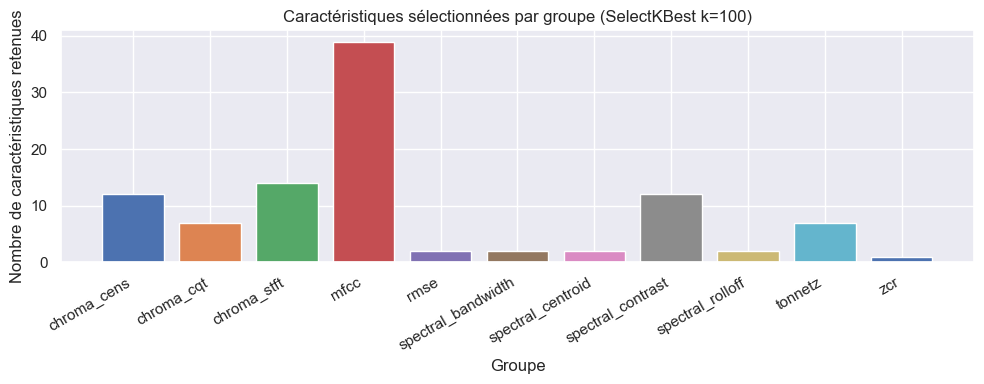

In [14]:
le = LabelEncoder()
y = le.fit_transform(genre_top)

selected_groups = {
    'chroma_cens': ['mean', 'std'],
    'chroma_cqt': ['mean', 'std'],
    'chroma_stft': ['mean', 'std'],
    'mfcc': ['mean', 'std'],
    'rmse': ['mean', 'std'],
    'spectral_bandwidth': ['mean', 'std'],
    'spectral_centroid': ['mean', 'std'],
    'spectral_contrast': ['mean', 'std'],
    'spectral_rolloff': ['mean', 'std'],
    'tonnetz': ['mean', 'std'],
    'zcr': ['mean', 'std'],
}

cols = []
for group, stats in selected_groups.items():
    for stat in stats:
        try:
            cols.append(feat_large[group][stat])
        except KeyError:
            print(f'  {group}/{stat} introuvable, ignoré.')

X_all = pd.concat(cols, axis=1).astype(float)
X_arr = np.nan_to_num(X_all.values, nan=0.0, posinf=0.0, neginf=0.0)
print(f'Caractéristiques avant sélection : {X_arr.shape[1]}')

selector = SelectKBest(f_classif, k=100)
X_sel = selector.fit_transform(X_arr, y)
print(f'Caractéristiques après SelectKBest(k=100) : {X_sel.shape[1]}')

feat_names = []
for group, stats in selected_groups.items():
    for stat in stats:
        try:
            n = feat_large[group][stat].shape[1]
            feat_names.extend([group] * n)
        except KeyError:
            pass

from collections import Counter
selected_mask = selector.get_support()
feat_names_arr = [feat_names[i] for i in range(len(feat_names)) if i < len(selected_mask)]
group_counts = Counter([feat_names_arr[i] for i, sel in enumerate(selected_mask) if sel])

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(group_counts.keys(), group_counts.values(), color=sns.color_palette('deep', len(group_counts)))
ax.set_title('Caractéristiques sélectionnées par groupe (SelectKBest k=100)')
ax.set_xlabel('Groupe')
ax.set_ylabel('Nombre de caractéristiques retenues')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Partie 6 – PCA (Réduction de dimensionnalité)

La **PCA (Principal Component Analysis)** transforme N features corrélées en nouveaux axes indépendants qui capturent le maximum de variance.

**Intuition :** si `chroma_cens.mean` et `chroma_cqt.mean` sont très corrélées, elles portent une information redondante. La PCA les fusionne en une seule composante qui résume les deux.

```
100 features → PCA → ~60 composantes (95% variance préservée)
```

**Seuil 95% :** on garde assez de composantes pour expliquer 95% de la variation dans les données. Les 5% restants = bruit ou information marginale.

**Limite :** les composantes ne sont plus interprétables — « composante 1 » est une combinaison linéaire de toutes les features originales, sans sens musical direct.

Composantes nécessaires pour expliquer 95 % de variance : 59


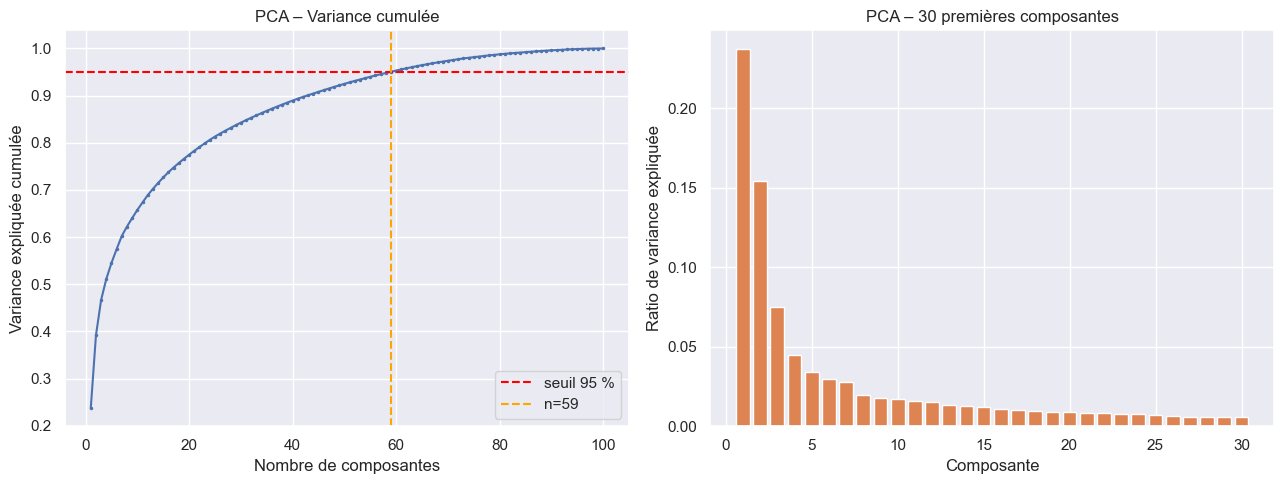

Dimensions sortie PCA : (17000, 59)


In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sel)

pca = PCA(random_state=RANDOM_STATE)
pca.fit(X_scaled)

cumvar = np.cumsum(pca.explained_variance_ratio_)
n95 = np.searchsorted(cumvar, 0.95) + 1
print(f'Composantes nécessaires pour expliquer 95 % de variance : {n95}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(np.arange(1, len(cumvar) + 1), cumvar, marker='.', ms=3)
axes[0].axhline(0.95, color='red', ls='--', label='seuil 95 %')
axes[0].axvline(n95, color='orange', ls='--', label=f'n={n95}')
axes[0].set_xlabel('Nombre de composantes')
axes[0].set_ylabel('Variance expliquée cumulée')
axes[0].set_title('PCA – Variance cumulée')
axes[0].legend()

axes[1].bar(range(1, 31), pca.explained_variance_ratio_[:30], color=sns.color_palette('deep')[1])
axes[1].set_xlabel('Composante')
axes[1].set_ylabel('Ratio de variance expliquée')
axes[1].set_title('PCA – 30 premières composantes')

plt.tight_layout()
plt.savefig('plots/pca_variance.png', dpi=120, bbox_inches='tight')
plt.show()

pca95 = PCA(n_components=n95, random_state=RANDOM_STATE)
X_pca = pca95.fit_transform(X_scaled)
print(f'Dimensions sortie PCA : {X_pca.shape}')

## Partie 7 – Classificateurs

On entraîne 3 classificateurs et on compare leurs performances sur la classification de genres.

 - **Régression logistique**

 - **Forêt aléatoire** 

 - **SVM** 

### 7.1 Division entraînement / test

In [31]:
indices = np.arange(len(y))
idx_tr, idx_te = train_test_split(indices, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

X_tr, X_te = X_scaled[idx_tr], X_scaled[idx_te]
Xp_tr, Xp_te = X_pca[idx_tr], X_pca[idx_te]
y_tr, y_te = y[idx_tr], y[idx_te]

print(f'Entraînement : {len(y_tr)} tracks')
print(f'Test         : {len(y_te)} tracks')

Entraînement : 13600 tracks
Test         : 3400 tracks


### 7.2 Entraînement des classificateurs

In [32]:
models = {
    'Régression logistique': LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=RANDOM_STATE),
    'Forêt aléatoire': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=RANDOM_STATE),
}

results = {}
print(f'{"Modèle":<25} {"Acc":>7} {"Préc":>7} {"Rap":>7} {"F1w":>7} {"F1m":>7}')
print('-' * 63)

for name, clf in models.items():
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1w = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    f1m = f1_score(y_te, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_te, y_pred)

    results[name] = dict(accuracy=acc, precision=prec, recall=rec, f1=f1w, f1_macro=f1m, cm=cm, y_pred=y_pred)
    print(f'{name:<25} {acc:>7.3f} {prec:>7.3f} {rec:>7.3f} {f1w:>7.3f} {f1m:>7.3f}')

Modèle                        Acc    Préc     Rap     F1w     F1m
---------------------------------------------------------------
Régression logistique       0.511   0.711   0.511   0.568   0.341
Forêt aléatoire             0.689   0.689   0.689   0.640   0.338
SVM (RBF)                   0.669   0.739   0.669   0.690   0.464


### 7.4 Prédictions sur échantillon test

Pour chaque track, on affiche le genre réel, le genre prédit, la tonalité et les métriques d'ambiance. ✓ = prédiction correcte, ✗ = erreur.

In [33]:
np.random.seed(RANDOM_STATE)
sample_idx = sorted(np.random.choice(len(idx_te), size=8, replace=False))
test_ids = feat_large.index[idx_te]
y_pred = results[best_name]['y_pred']

print('=== Prédictions sur l\'échantillon test ===\n')
print(f'{"ID":>6}  {"Réel":<16} {"Prédit":<16} {"Clé":>4}  {"✓/✗":>4}  {"Énerg":>5} {"Dans":>5} {"Joie":>5} {"Voix":>5} {"Instr":>5} {"Vol":>5}')
print('-' * 95)

for si in sample_idx:
    ti = test_ids[si]
    real = le.inverse_transform([y_te[si]])[0]
    pred = le.inverse_transform([y_pred[si]])[0]
    row = mood_df.loc[ti]
    print(f'{ti:>6}  {real:<16} {pred:<16} {row["key"]:>4}  {"✓" if real==pred else "✗":>4}  '
          f'{row["energy"]:>5.2f} {row["danceability"]:>5.2f} {row["happiness"]:>5.2f} '
          f'{row["speechiness"]:>5.2f} {row["instrumentalness"]:>5.2f} {row["loudness"]:>5.2f}')

NameError: name 'best_name' is not defined

## Partie 8 – Comparaison des modèles & Conclusion

### 8.1 Comparaison des performances

=== Comparaison finale des modèles ===
                       accuracy  precision  recall     f1  f1_macro
Régression logistique    0.5109     0.7112  0.5109 0.5682    0.3411
Forêt aléatoire          0.6891     0.6889  0.6891 0.6396    0.3380
SVM (RBF)                0.6688     0.7386  0.6688 0.6896    0.4643


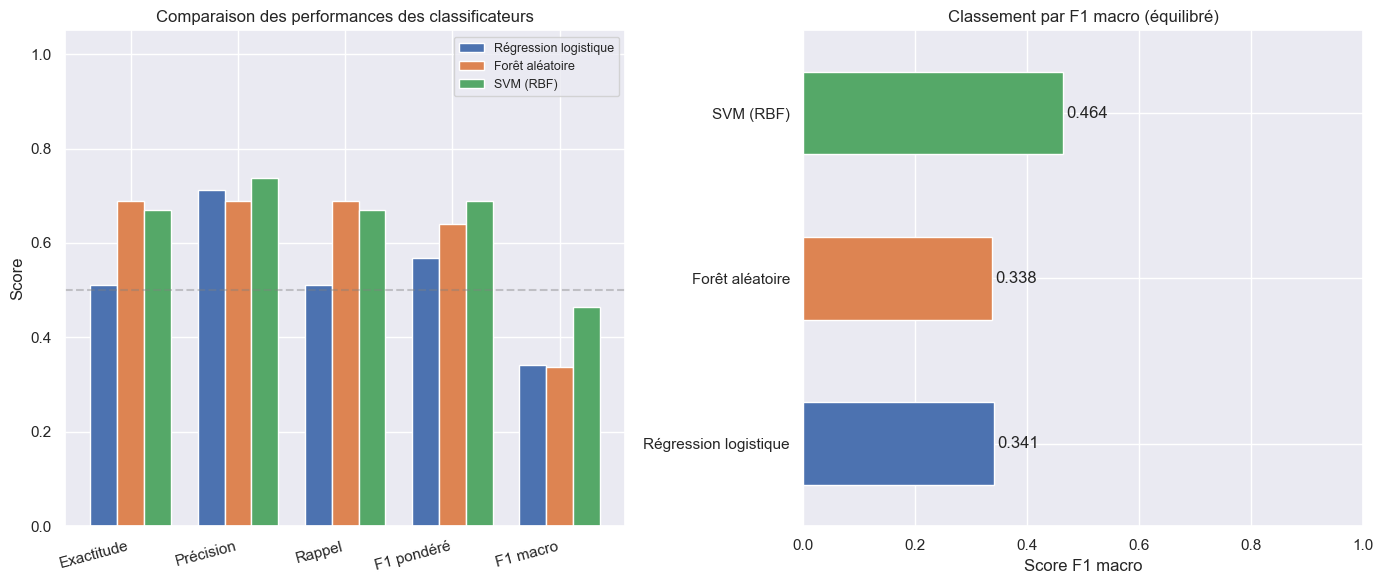

In [ ]:
results_df = pd.DataFrame({
    name: {k: v for k, v in res.items() if k not in ('cm', 'y_pred')}
    for name, res in results.items()
}).T.astype(float)

print('=== Comparaison finale des modèles ===')
print(results_df.to_string(float_format='{:.4f}'.format))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metrics = ['accuracy', 'precision', 'recall', 'f1', 'f1_macro']
metrics_labels = ['Exactitude', 'Précision', 'Rappel', 'F1 pondéré', 'F1 macro']
x = np.arange(len(metrics))
width = 0.25
colors = sns.color_palette('deep', len(results_df))

for j, (name, row) in enumerate(results_df.iterrows()):
    axes[0].bar(x + j * width, [row[m] for m in metrics], width, label=name, color=colors[j])

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics_labels, rotation=15, ha='right')
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Score')
axes[0].set_title('Comparaison des performances des classificateurs')
axes[0].legend(fontsize=9)
axes[0].axhline(0.5, color='gray', ls='--', alpha=0.4)

results_df['f1_macro'].plot.barh(ax=axes[1], color=colors)
axes[1].set_xlabel('Score F1 macro')
axes[1].set_title('Classement par F1 macro (équilibré)')
axes[1].set_xlim(0, 1)
for i, v in enumerate(results_df['f1_macro']):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## Conclusion

AREMPLIR